# Variants TMT Dataset EDA
Please make sure to download the dataset and label it as "variants_tmt.tsv". Place in the root folder.


In [20]:
import pandas as pd

# Load the file
variants = pd.read_csv("variants_tmt.tsv", sep="\t", low_memory=False)

# Basic exploration — run each of these one at a time
print("Shape (rows, columns):", variants.shape)      # How big is it?
print("\nFirst few column names:")
print(variants.columns[:10].tolist())                # First 10 columns
print("\nFirst 3 rows:")
variants.head(3)                                     # Preview the data

Shape (rows, columns): (101461, 268)

First few column names:
['rowid', 'ccms_row_id', 'Algorithm', 'Filename', 'Cluster_index', 'Peptide', 'Unmodified_sequence', 'Charge', '_dyn_#Intensity_for_cluster', '_dyn_#Intensity_for_unmodified_sequence']

First 3 rows:


,rowid,ccms_row_id,Algorithm,Filename,Cluster_index,Peptide,Unmodified_sequence,Charge,_dyn_#Intensity_for_cluster,_dyn_#Intensity_for_unmodified_sequence,...,PSP_site_match,DrugBank_drugs,Parent_mass,Num_PSP_Drugbank_events,Start_AA_1_based,End_AA_1_based,Num_spectra_for_cluster,Num_spectra_for_unmodified_sequence,Num_spectra_for_peptide_variant,Internal_ref_orig_intensity
0,1,1,.MODA.,specs_ms.mgf,960991,"K.[304.207]GARLIPEMDQIFTEVEMTTLE(K,304.207).V",.GARLIPEMDQIFTEVEMTTLEK.,4,36.905893,36.905893,...,NaN,NaN,1580.81,0,NaN,NaN,1,1,1,8204.159180
1,2,2,.MODA.,specs_ms.mgf,763982,"I.[304.207]FTEVEMTTLE(K,304.207).V",.FTEVEMTTLEK.,3,11.686782,11.686782,...,NaN,NaN,1934.91,0,NaN,NaN,1,2,2,493689.437500
2,3,3,.MSGFPLUS.,specs_ms.mgf,902201,K.[304.207]LYQPEYQEVSTEEQR.E,.LYQPEYQEVSTEEQR.,3,15.690234,15.690234,...,NaN,NaN,2203.09,0,NaN,NaN,5,6,6,195156.578125


In [21]:
# Find all columns that contain patient intensity measurements
intensity_cols = [c for c in variants.columns if 'intensity_for_peptide_variant' in c]

print("Number of patient intensity columns:", len(intensity_cols))
print("\nFirst 5 patient columns:")
print(intensity_cols[:5])
print("\nLast 5 patient columns:")
print(intensity_cols[-5:])

Number of patient intensity columns: 92

First 5 patient columns:
['_dyn_#Empty.Empty.Empty..Empty.1_intensity_for_peptide_variant', '_dyn_#Healthy.HC1.Healthy..HC1.1_intensity_for_peptide_variant', '_dyn_#Healthy.HC10.Healthy..HC10.1_intensity_for_peptide_variant', '_dyn_#Healthy.HC12.Healthy..HC12.1_intensity_for_peptide_variant', '_dyn_#Healthy.HC13.Healthy..HC13.1_intensity_for_peptide_variant']

Last 5 patient columns:
['_dyn_#Symptomatic-non-COVID-19.JBDZ6.Symptomatic-non-COVID-19..JBDZ6.1_intensity_for_peptide_variant', '_dyn_#Symptomatic-non-COVID-19.JBDZ7.Symptomatic-non-COVID-19..JBDZ7.1_intensity_for_peptide_variant', '_dyn_#Symptomatic-non-COVID-19.JBDZ8.Symptomatic-non-COVID-19..JBDZ8.1_intensity_for_peptide_variant', '_dyn_#Symptomatic-non-COVID-19.JBDZ9.Symptomatic-non-COVID-19..JBDZ9.1_intensity_for_peptide_variant', '_dyn_#Symptomatic-non-COVID-19.Patient-group-jbdz.Symptomatic-non-COVID-19..Patient-group-jbdz.1_intensity_for_peptide_variant']


In [22]:
# Extract just the class name from each intensity column
classes = [c.split('.')[0].replace('_dyn_#', '') for c in intensity_cols]

# Count how many columns belong to each class
import pandas as pd
class_counts = pd.Series(classes).value_counts()
print(class_counts)

Symptomatic-non-COVID-19    25
Non-severe-COVID-19         25
Healthy                     22
Severe-COVID-19             18
Empty                        1
Norm                         1
Name: count, dtype: int64


In [23]:
# Remove Empty and Norm columns, keep only real patient columns
real_patient_cols = [c for c in intensity_cols 
                     if not c.startswith('_dyn_#Empty') 
                     and not c.startswith('_dyn_#Norm')]

print("Real patient columns:", len(real_patient_cols))

Real patient columns: 90


In [24]:
# Keep only the Peptide column + the 90 real patient intensity columns
variants_processed = variants[['Peptide'] + real_patient_cols]

print("New shape:", variants_processed.shape)
print("\nFirst 3 columns:", variants_processed.columns[:3].tolist())
print("Last 3 columns:", variants_processed.columns[-3:].tolist())

New shape: (101461, 91)

First 3 columns: ['Peptide', '_dyn_#Healthy.HC1.Healthy..HC1.1_intensity_for_peptide_variant', '_dyn_#Healthy.HC10.Healthy..HC10.1_intensity_for_peptide_variant']
Last 3 columns: ['_dyn_#Symptomatic-non-COVID-19.JBDZ8.Symptomatic-non-COVID-19..JBDZ8.1_intensity_for_peptide_variant', '_dyn_#Symptomatic-non-COVID-19.JBDZ9.Symptomatic-non-COVID-19..JBDZ9.1_intensity_for_peptide_variant', '_dyn_#Symptomatic-non-COVID-19.Patient-group-jbdz.Symptomatic-non-COVID-19..Patient-group-jbdz.1_intensity_for_peptide_variant']


In [25]:
# Step 1 - Replace 0s with NaN
variants_processed = variants_processed.replace(0.0, float('nan'))

# Step 2 - Make Peptide the index
variants_processed = variants_processed.set_index('Peptide')

# Step 3 - Transpose so rows=patients, columns=peptides
variants_processed = variants_processed.T

print("Shape after transpose:", variants_processed.shape)
print("\nFirst 3 row names (patients):")
print(variants_processed.index[:3].tolist())

Shape after transpose: (90, 101461)

First 3 row names (patients):
['_dyn_#Healthy.HC1.Healthy..HC1.1_intensity_for_peptide_variant', '_dyn_#Healthy.HC10.Healthy..HC10.1_intensity_for_peptide_variant', '_dyn_#Healthy.HC12.Healthy..HC12.1_intensity_for_peptide_variant']


In [26]:
# Shorten the row names to just "Class.PatientID"
variants_processed.index = variants_processed.index.map(
    lambda x: '.'.join(x.replace('_dyn_#', '').split('.')[:2])
)

# Add a Condition column showing just the class (e.g. "Healthy")
variants_processed['Condition'] = variants_processed.index.map(
    lambda x: x.split('.')[0]
)

print("First 5 row names:", variants_processed.index[:5].tolist())
print("\nCondition counts:")
print(variants_processed['Condition'].value_counts())

First 5 row names: ['Healthy.HC1', 'Healthy.HC10', 'Healthy.HC12', 'Healthy.HC13', 'Healthy.HC17']

Condition counts:
Condition
Non-severe-COVID-19         25
Symptomatic-non-COVID-19    25
Healthy                     22
Severe-COVID-19             18
Name: count, dtype: int64


In [27]:
# Keep only Severe and Non-severe COVID-19 patients
variants_filtered = variants_processed[
    (variants_processed['Condition'] == 'Severe-COVID-19') |
    (variants_processed['Condition'] == 'Non-severe-COVID-19')
]

print("Shape after filtering:", variants_filtered.shape)
print("\nCondition counts:")
print(variants_filtered['Condition'].value_counts())

Shape after filtering: (43, 101462)

Condition counts:
Condition
Non-severe-COVID-19    25
Severe-COVID-19        18
Name: count, dtype: int64


In [28]:
# Save just Severe vs Non-severe (43 patients)
variants_filtered.to_csv("variants_filtered.tsv", sep="\t")
print("Saved variants_filtered.tsv")

Saved variants_filtered.tsv


## Summary — Data Loading & Cleaning. Refer to checkpoints/checkpoint1.md

Goal: Prepare a dataset to classify Severe vs Non-severe COVID-19 patients using blood protein measurements.

Dataset: Proteomic and Metabolomic Characterization of COVID-19 Patient Sera (MSV000085507)

What we did:
We started with the raw Variants TMT file (variants_tmt.tsv) — a large 414MB spreadsheet with 101,461 peptide variants measured across 92 sample columns. We identified and removed 2 non-patient lab channels (Empty and Norm), leaving 90 real patients across 4 classes. We then cleaned the data by replacing zero intensity values with NaN, since zeros are not meaningful measurements in mass spectrometry. We transposed the matrix so that each row represents a patient and each column represents a peptide. Finally, we filtered down to only the 43 patients relevant to our classification task — 18 Severe and 25 Non-severe COVID-19 patients — and saved this as variants_filtered.tsv.

End result:
43 patients × 101,461 peptides

├── Severe-COVID-19:      18 patients

└── Non-severe-COVID-19:  25 patients

## Checkpoint 2 — Data Exploration & Visualization

Goal: Understand what the data looks like before building any models.

Steps:
1. Reload `variants_filtered.tsv` (43 patients × 101,461 peptides)
2. Check missing values per peptide and per patient
3. Histogram — intensity distribution of one peptide for Severe vs Non-severe
4. Scatter plot — two peptides plotted against each other
5. Heatmap — intensity patterns across all patients for the top peptides

### Step 1 — Reload the cleaned data

In [29]:
import pandas as pd

df = pd.read_csv("variants_filtered.tsv", sep="\t", index_col=0)

# Separate the intensity data from the condition label
condition = df["Condition"]
X = df.drop(columns=["Condition"])

print(f"Patients : {X.shape[0]}")
print(f"Peptides : {X.shape[1]}")
print(f"\nCondition counts:")
print(condition.value_counts())

Patients : 43
Peptides : 101461

Condition counts:
Condition
Non-severe-COVID-19    25
Severe-COVID-19        18
Name: count, dtype: int64


### Step 2 — Missing Values

Check how many NaNs exist per patient (row) and per peptide (column).  
This tells us whether missingness is concentrated in specific patients or specific peptides.

In [30]:
total_values = X.size
total_na     = X.isna().sum().sum()
print(f"Total values : {total_values:,}")
print(f"Missing (NaN): {total_na:,}  ({100 * total_na / total_values:.1f}%)\n")

# NaNs per patient (row)
na_per_patient = X.isna().sum(axis=1).sort_values(ascending=False)
print("NaNs per patient (all 43):")
print(na_per_patient.to_string())

# Summary of NaNs per peptide (column)
na_per_peptide = X.isna().sum(axis=0)
print(f"\nPeptide missingness summary:")
print(na_per_peptide.describe().round(1))
print(f"\nPeptides with 0 NaNs (complete): {(na_per_peptide == 0).sum():,}")
print(f"Peptides missing in ALL patients: {(na_per_peptide == len(X)).sum():,}")

Total values : 4,362,823
Missing (NaN): 2,572,969  (59.0%)

NaNs per patient (all 43):
Non-severe-COVID-19.XG5                 67799
Non-severe-COVID-19.XG4                 67715
Severe-COVID-19.XG31                    67592
Non-severe-COVID-19.XG6                 67561
Severe-COVID-19.XG29                    67466
Non-severe-COVID-19.XG8                 66306
Non-severe-COVID-19.XG7                 66244
Severe-COVID-19.XG33                    66158
Severe-COVID-19.XG35                    66146
Non-severe-COVID-19.XG9                 66120
Severe-COVID-19.XG34                    66120
Severe-COVID-19.XG37                    65245
Non-severe-COVID-19.XG11                65240
Non-severe-COVID-19.XG10                65179
Severe-COVID-19.XG36                    65170
Non-severe-COVID-19.XG13                65108
Non-severe-COVID-19.XG19                59950
Non-severe-COVID-19.XG18                59934
Non-severe-COVID-19.XG17                59907
Severe-COVID-19.XG40                   

### Step 3 — Histogram

Pick one well-measured peptide and compare its intensity distribution between Severe and Non-severe patients.  
We choose the peptide with the fewest missing values so we have the most data to plot.

Chosen peptide: R.[304.207]QQQHLFGSNVTD(C,57.021)SGNF(C,57.021)LFR.S
Missing values: 0 / 43 patients



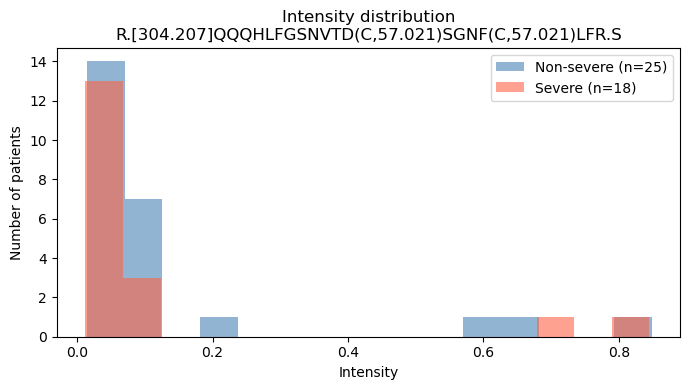

In [31]:
import matplotlib.pyplot as plt

# Pick the peptide with the fewest NaNs
best_peptide = na_per_peptide.idxmin()
print(f"Chosen peptide: {best_peptide}")
print(f"Missing values: {na_per_peptide[best_peptide]} / {len(X)} patients\n")

severe     = X.loc[condition == "Severe-COVID-19",     best_peptide].dropna()
non_severe = X.loc[condition == "Non-severe-COVID-19", best_peptide].dropna()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(non_severe, bins=15, alpha=0.6, label=f"Non-severe (n={len(non_severe)})", color="steelblue")
ax.hist(severe,     bins=15, alpha=0.6, label=f"Severe (n={len(severe)})",         color="tomato")
ax.set_xlabel("Intensity")
ax.set_ylabel("Number of patients")
ax.set_title(f"Intensity distribution\n{best_peptide[:60]}")
ax.legend()
plt.tight_layout()
plt.show()

### Step 4 — Scatter Plot

Plot two peptides against each other — one point per patient, coloured by condition.  
If the two groups cluster separately, those peptides together carry discriminative signal.

X-axis peptide: R.[304.207]QQQHLFGSNVTD(C,57.021)SGNF(C,57.021)LFR.S
Y-axis peptide: R.[304.207]QQQHLF(G,304.219)SNVTD(C,57.021)SGNF(C,57.021)LFR


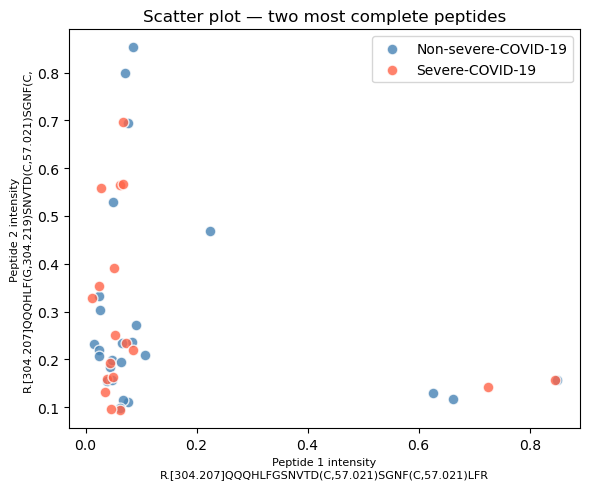

In [32]:
# Pick the 2 most complete peptides (fewest NaNs)
top2 = na_per_peptide.nsmallest(2).index.tolist()
pep_x, pep_y = top2[0], top2[1]
print(f"X-axis peptide: {pep_x[:60]}")
print(f"Y-axis peptide: {pep_y[:60]}")

colors = {"Severe-COVID-19": "tomato", "Non-severe-COVID-19": "steelblue"}

fig, ax = plt.subplots(figsize=(6, 5))
for cond, grp in df.groupby("Condition"):
    ax.scatter(grp[pep_x], grp[pep_y],
               label=cond, color=colors[cond], alpha=0.8, edgecolors="white", s=60)

ax.set_xlabel(f"Peptide 1 intensity\n{pep_x[:50]}", fontsize=8)
ax.set_ylabel(f"Peptide 2 intensity\n{pep_y[:50]}", fontsize=8)
ax.set_title("Scatter plot — two most complete peptides")
ax.legend()
plt.tight_layout()
plt.show()

### Step 5 — Heatmap

Visualize intensity patterns across all 43 patients for the top 50 peptides by variance (most variable = most likely to differ between groups).  
Patients are sorted by condition so Severe and Non-severe appear as distinct blocks.

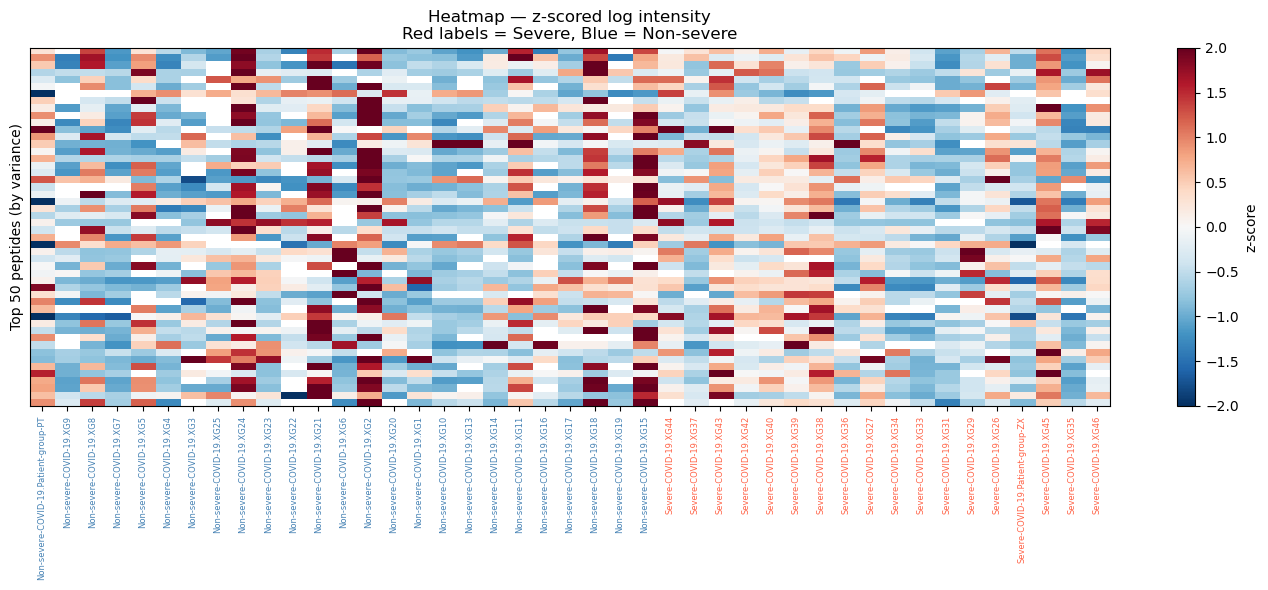

In [33]:
import numpy as np

# Select top 50 peptides by variance (ignoring NaNs), from peptides present in ≥80% of patients
min_present = int(0.8 * len(X))
well_covered = X.columns[X.notna().sum() >= min_present]
top50 = X[well_covered].var().nlargest(50).index

# Sort patients: Non-severe first, then Severe
patient_order = condition.sort_values().index
heatmap_data = X.loc[patient_order, top50]

# Log-transform to compress the dynamic range, then z-score each peptide
heatmap_log = np.log1p(heatmap_data)
heatmap_z   = (heatmap_log - heatmap_log.mean()) / heatmap_log.std()

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(heatmap_z.T, aspect="auto", cmap="RdBu_r", vmin=-2, vmax=2)

# X-axis: patient labels, coloured by condition
ax.set_xticks(range(len(patient_order)))
ax.set_xticklabels(patient_order, rotation=90, fontsize=6)
for tick, pat in zip(ax.get_xticklabels(), patient_order):
    tick.set_color("tomato" if condition[pat] == "Severe-COVID-19" else "steelblue")

ax.set_yticks([])
ax.set_ylabel("Top 50 peptides (by variance)")
ax.set_title("Heatmap — z-scored log intensity\nRed labels = Severe, Blue = Non-severe")
plt.colorbar(im, ax=ax, label="z-score")
plt.tight_layout()
plt.show()